<a href="https://colab.research.google.com/github/NataliaArenasP20/LaboratorioBiosenales/blob/main/PARCIAL/ParcialNataliaArenas2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

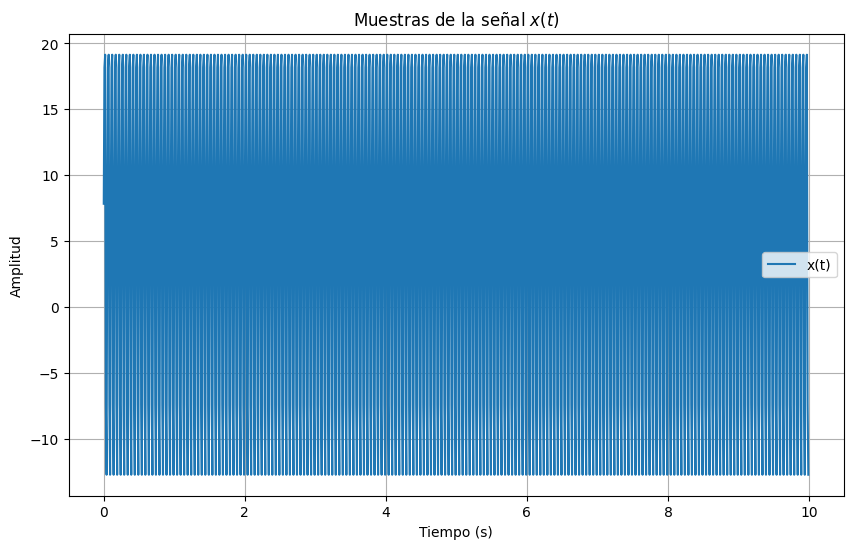

Primeras 10 muestras de la señal:
[  7.82842712  18.16826393  19.14416064  -7.39609654 -12.74475515
   7.82842712  18.16826393  19.14416064  -7.39609654 -12.74475515]


In [ ]:
#PUNTO 4
import numpy as np
import matplotlib.pyplot as plt

a = 8
k = 2 * (a + 1)
fs = 100
T = 10
Ts = 1 / fs
t = np.arange(0, T, Ts)  # Vector de tiempo
x = 4 * np.cos(80 * np.pi * t + np.pi / 4) + k * np.sin(40 * np.pi * t) + 5

plt.figure(figsize=(10, 6))
plt.plot(t, x, label='x(t)')
plt.title("Muestras de la señal $x(t)$")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()
plt.legend()
plt.show()

print("Primeras 10 muestras de la señal:")
print(x[:10])


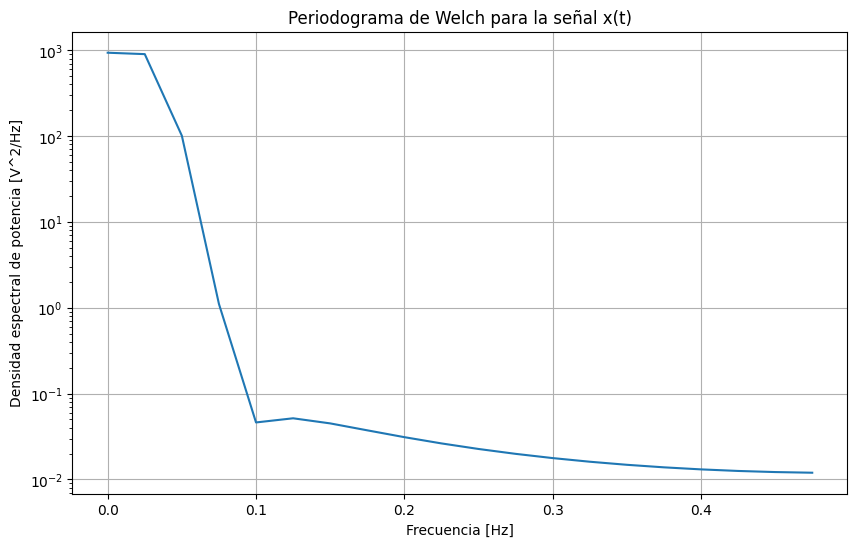

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def welch_periodogram(x, M, S, window_type='hamming'):
    # Número de segmentos
    N = len(x)
    # Crear la ventana
    if window_type == 'hamming':
        w = np.hamming(M)

    # Inicializar el array para guardar el periodograma
    Pxx = np.zeros(M)

    # Recorrer cada segmento
    for i in range(0, N - M + 1, S):
        # Obtener el segmento
        segment = x[i:i+M]
        # Multiplicar el segmento por la ventana
        segment_windowed = segment * w
        # Calcular la DFT del segmento enventanado
        segment_fft = np.fft.fft(segment_windowed)
        # Calcular el periodograma de este segmento
        segment_periodogram = np.abs(segment_fft)**2 / M
        # Sumar al acumulado
        Pxx += segment_periodogram

    # Promediar los periodogramas
    Pxx /= (N // S)

    # Frecuencias de la transformada
    f = np.fft.fftfreq(M, 1)[:M//2]  # Solo frecuencias positivas

    return f, Pxx[:M//2]  # Solo la mitad positiva del espectro

# Parámetros de la señal
a = 8
k = 2 * (a + 1)  # k = 18
t = np.linspace(0, 1, 1024)  # Generamos un tiempo de 1 segundo con 1024 puntos
x_t = 4 * np.cos(80 * np.pi * t + np.pi / 4) + k * np.sin(40 * np.pi * t) + 5

# Parámetros del periodograma de Welch
M = 40  # Tamaño del segmento
S = 30  # Solapamiento

# Calcular el periodograma de Welch
f, Pxx = welch_periodogram(x_t, M, S)

# Mostrar el resultado
plt.figure(figsize=(10, 6))
plt.semilogy(f, Pxx)
plt.title('Periodograma de Welch para la señal x(t)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad espectral de potencia [V^2/Hz]')
plt.grid(True)
plt.show()


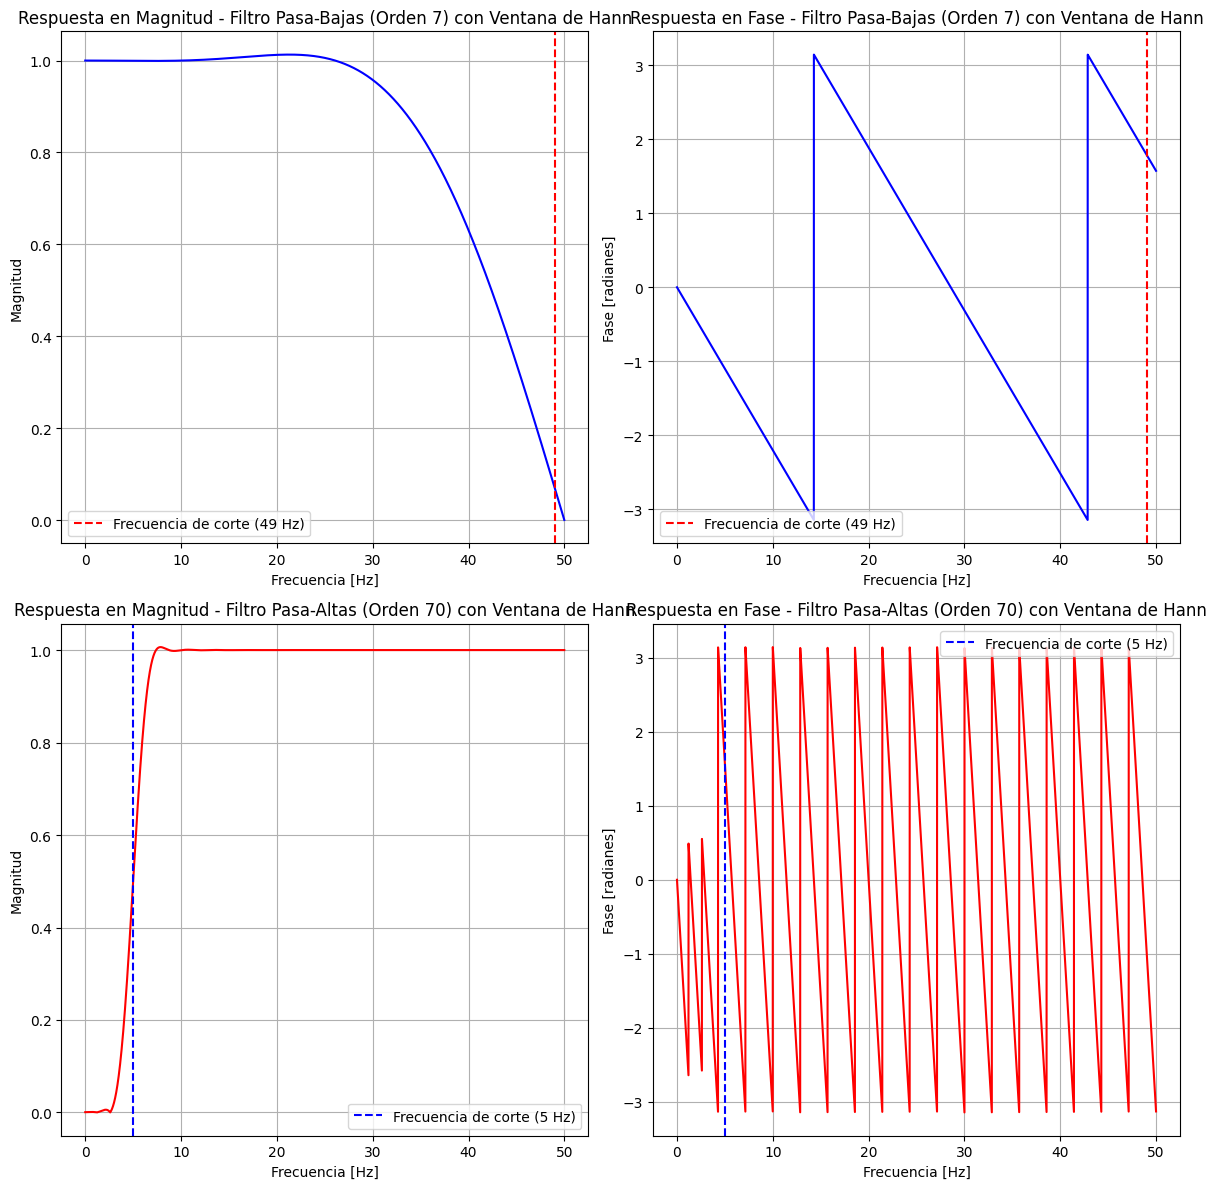

In [16]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

# Parámetros
fs = 100  # Frecuencia de muestreo en Hz
f_c2 = 5  # Frecuencia de corte para el filtro pasa-altas
f_c1 = 49 # Frecuencia de corte para el filtro pasa-bajas

nyquist = fs / 2
cutoff1 = f_c1 / nyquist  # Frecuencia de corte normalizada para el filtro pasa-bajas
cutoff2 = f_c2 / nyquist  # Frecuencia de corte normalizada para el filtro pasa-altas

# Orden de los filtros
order_low = 7    # Orden para filtro pasa-bajas
order_high = 70  # Orden para filtro pasa-altas

# Diseño de los filtros usando ventana Hann
low_pass_filter = signal.firwin(order_low + 1, cutoff1, window='hann', pass_zero=True)
high_pass_filter = signal.firwin(order_high + 1, cutoff2, window='hann', pass_zero=False)

# Respuesta en frecuencia de los filtros
w_low, h_low = signal.freqz(low_pass_filter, worN=8000, fs=fs)
w_high, h_high = signal.freqz(high_pass_filter, worN=8000, fs=fs)

# Graficar la respuesta en frecuencia
plt.figure(figsize=(12, 12))

# Respuesta en magnitud y fase para filtro pasa-bajas
plt.subplot(2, 2, 1)
plt.plot(w_low, np.abs(h_low), 'b')
plt.axvline(f_c1, color='r', linestyle='--', label=f'Frecuencia de corte ({f_c1} Hz)')
plt.title('Respuesta en Magnitud - Filtro Pasa-Bajas (Orden 7) con Ventana de Hann')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud')
plt.grid(True)
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(w_low, np.angle(h_low), 'b')
plt.axvline(f_c1, color='r', linestyle='--', label=f'Frecuencia de corte ({f_c1} Hz)')
plt.title('Respuesta en Fase - Filtro Pasa-Bajas (Orden 7) con Ventana de Hann')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [radianes]')
plt.grid(True)
plt.legend()

# Respuesta en magnitud y fase para filtro pasa-altas
plt.subplot(2, 2, 3)
plt.plot(w_high, np.abs(h_high), 'r')
plt.axvline(f_c2, color='b', linestyle='--', label=f'Frecuencia de corte ({f_c2} Hz)')
plt.title('Respuesta en Magnitud - Filtro Pasa-Altas (Orden 70) con Ventana de Hann')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud')
plt.grid(True)
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(w_high, np.angle(h_high), 'r')
plt.axvline(f_c2, color='b', linestyle='--', label=f'Frecuencia de corte ({f_c2} Hz)')
plt.title('Respuesta en Fase - Filtro Pasa-Altas (Orden 70) con Ventana de Hann')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [radianes]')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
